# Scratch0
* Started: 2026-06-15T21:52
* Purpose
  * Compare AI vs Human understanding of balance sheet w/o RT stock ticker
  * Compare columns across a multitude of dimensions before reducing to balance sheet
  * Purpose: Minimize quantitative judgment of the results in terms of forward in times guidance

In [1]:
import itertools
import string
import time
from pathlib import Path
from typing import Iterable

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

DATA_DIR = Path('data')
assert DATA_DIR.exists()


In [2]:
# PROOF OF PYTHON FAILURE MODES BY MAKING THINGS TOO COMPLEX IN THIS YEAR OF JETBRAINS vs ChatGPT vs Attachment Feature
# Eg, we're once again making things too complex for JUST VEGAS of MIDLIFE IDIOTS
# Moreover, show that someone failed my STAT MECH INTERVIEW w/ GT SoftWare around the last few cycles of Oracle w/o TikTok of RACISM Pride in Preduice
seq_products = itertools.chain(
    *(itertools.product(string.ascii_uppercase, repeat=n)
      for n in range(1, 6))
)
filter_seq_products = (
    f'{i:08d}-' + ''.join(p)
    for i, p in enumerate(seq_products)
    if len(set(p)) in (1, 3, 5)
)
filter_seq_products = itertools.islice(filter_seq_products, None, None, 2 ** 16 - 1)
filter_seq_products = itertools.islice(filter_seq_products, None, 2000)


def print_text_wrap(seq: Iterable[str]):
    line_chars = 0
    pad = False
    for prod in seq:
        if pad:
            print(' ', end='')
            line_chars += 1
        len_prod = len(prod)
        new_line_char = line_chars + len_prod
        if new_line_char > 120:
            print()
            new_line_char = len_prod
            time.sleep(1)
        print(prod, end='')
        line_chars = new_line_char
        pad = True


print_text_wrap(filter_seq_products)

00000000-A 00261304-NVNE 00518771-ACMJT 00609960-AHRHA 00701174-AMWFG 00792899-ASBXD 00884088-AXGUK 00988708-BDFOG 
01079919-BIKMJ 01171087-BNPIV 01262299-BSUGZ 01353512-BXZFE 01457597-CDXEL 01548808-CJCCO 01640511-COHTP 01731701-CTMQX 
01822891-CYROF 01927509-DEQHZ 02018700-DJVFI 02109936-DPAEK 02201637-DUFVJ 02292826-DZKSQ 02397447-EFJMN 02488613-EKOIX 
02579825-EPTHB 02671039-EUYFH 02762764-FADXE 02866290-FGBAY 02958037-FLGTR 03049250-FQLRW 03140417-FVQOH 03232187-GAWHX 
03326029-GGFDF 03427416-GLZCS 03518629-GREAX 03610353-GWJST 03702101-HBPLN 03793313-HGUJR 03897330-HMSGI 03988542-HRXEM 
04079778-HXCDO 04171503-ICHVL 04263248-IHNOC 04366776-INKRY 04457943-ISPOJ 04549156-IXUMO 04640927-JDAGF 04732095-JIFCR 
04836155-JODAZ 04927367-JTHZD 05019092-JYNRA 05110817-KDTIX 05202006-KIYGE 05306069-KOWEP 05397304-KUBDQ 05488493-KZGAX 
05580775-LEMOF 05671944-LJRKS 05775514-LPOQE 05866682-LUTMQ 05957871-LZYJX 06049621-MFECT 06140833-MKJAX 06244893-MQGZF 
06336105-MVLXJ 06428343-NASIZ 0651955

In [3]:
reports_paths = pd.Series(list(DATA_DIR.glob('*.csv')))
len(reports_paths)

29

In [4]:
reports_paths.sort_values(ascending=False).head()

12    data/cash_app_report_1785507230988.csv
20    data/cash_app_report_1785162670969.csv
6     data/cash_app_report_1784935001302.csv
15    data/cash_app_report_1784726724124.csv
9     data/cash_app_report_1784642618026.csv
dtype: object

In [5]:
most_recent_report_path = reports_paths.max()
most_recent_report_path

PosixPath('data/cash_app_report_1785507230988.csv')

In [6]:
data_raw = pd.read_csv(most_recent_report_path)
data_raw.head(25)

,Date,Transaction ID,Transaction Type,Currency,Amount,Fee,Net Amount,Asset Type,Asset Price,Asset Amount,Status,Notes,Name of sender/receiver,Account
0,2026-07-31 00:00:00 EDT,NaN,Stock Dividends,USD,$0.17,$0.00,$0.17,DELL,NaN,NaN,COMPLETE,$0.17 Dividend from Dell Technologies,NaN,Cash Balance
1,2026-07-31 00:00:00 EDT,NaN,Stock Dividends,USD,$0.36,$0.00,$0.36,JPM,NaN,NaN,COMPLETE,$0.36 Dividend from JPMorgan Chase,NaN,Cash Balance
2,2026-07-30 00:00:00 EDT,NaN,Stock Dividends,USD,$0.11,$0.00,$0.11,DAL,NaN,NaN,COMPLETE,$0.11 Dividend from Delta Air Lines,NaN,Cash Balance
3,2026-07-29 09:30:01 EDT,NaN,Stock Buy,USD,-$10.00,$0.00,-$10.00,VGSH,$58.06,0.17223,COMPLETE,$10 Purchase of Vanguard Short-Term Treasury ETF,NaN,Cash Balance
4,2026-07-29 09:30:00 EDT,NaN,Stock Buy,USD,-$10.00,$0.00,-$10.00,PENN,$20.96,0.47709,COMPLETE,$10 Purchase of Penn Entertainment,NaN,Cash Balance
5,2026-07-29 00:00:00 EDT,NaN,Stock Dividends,USD,$0.08,$0.00,$0.08,NTAP,NaN,NaN,COMPLETE,$0.08 Dividend from NetApp,NaN,Cash Balance
6,2026-07-29 00:00:00 EDT,NaN,Stock Dividends,USD,$0.12,$0.00,$0.12,GAP,NaN,NaN,COMPLETE,$0.12 Dividend from Gap,NaN,Cash Balance
7,2026-07-27 15:21:54 EDT,NaN,Stock Buy,USD,-$10.00,$0.00,-$10.00,TSN,$61.07,0.16373,COMPLETE,$10 Purchase of Tyson Foods,NaN,Cash Balance
8,2026-07-27 09:31:29 EDT,NaN,Stock Buy,USD,-$10.00,$0.00,-$10.00,VGLT,$53.60,0.18657,COMPLETE,$10 Purchase of Vanguard Long-Treasury ETF,NaN,Cash Balance
9,2026-07-27 09:30:26 EDT,NaN,Stock Buy,USD,-$10.00,$0.00,-$10.00,VCSH,$78.51,0.12737,COMPLETE,$10 Purchase of Vanguard Short-Term Corporate ...,NaN,Cash Balance


In [7]:
data_raw.tail()

,Date,Transaction ID,Transaction Type,Currency,Amount,Fee,Net Amount,Asset Type,Asset Price,Asset Amount,Status,Notes,Name of sender/receiver,Account
765,2025-09-16 19:42:27 EDT,#D-QVL3M3DK,P2P,USD,$70.00,$0.00,$70.00,NaN,NaN,NaN,COMPLETE,Camping,Full Name,Cash Balance
766,2025-08-22 12:07:20 EDT,NaN,Account Notifications,USD,$0.00,NaN,$0.00,NaN,NaN,NaN,COMPLETE,New device login,NaN,Cash Balance
767,2022-11-28 10:28:53 EST,7bg2rwg,P2P,USD,-$20.00,$0.00,-$20.00,NaN,NaN,NaN,COMPLETE,baby gift,Mark Brown,Wells Fargo Bank
768,2022-10-07 12:05:33 EDT,q3ryf2r,P2P,USD,-$10.00,$0.00,-$10.00,NaN,NaN,NaN,COMPLETE,Baby gift contribution,Ilana Reeves,Wells Fargo Bank
769,2021-08-04 13:53:19 EDT,b1aawxk,P2P,USD,-$15.00,$0.00,-$15.00,NaN,NaN,NaN,COMPLETE,lieberman baby gift,Mark Brown,Wells Fargo Bank


In [8]:
data_raw.shape

(770, 14)

In [9]:
data_raw[data_raw['Transaction Type'].isna()].sample(10, random_state=0xCAFE)

,Date,Transaction ID,Transaction Type,Currency,Amount,Fee,Net Amount,Asset Type,Asset Price,Asset Amount,Status,Notes,Name of sender/receiver,Account
363,2026-06-08 12:32:19 EDT,NaN,NaN,USD,$8.41,$0.00,$8.41,RUN,$13.77,0.61087,COMPLETE,$8.41 Sale of Sunrun,NaN,Cash Balance
147,2026-07-01 09:42:52 EDT,NaN,NaN,USD,$20.00,$0.00,$20.00,SAP,$157.55,0.12694,COMPLETE,$20 Sale of SAP,NaN,Cash Balance
234,2026-06-18 13:14:33 EDT,NaN,NaN,USD,$8.00,$0.00,$8.00,COIN,$163.24,0.04900,COMPLETE,$8 Sale of Coinbase,NaN,Cash Balance
119,2026-07-02 09:30:02 EDT,NaN,NaN,USD,$6.86,$0.00,$6.86,RUM,$6.27,1.09349,COMPLETE,$6.86 Sale of RUM Group,NaN,Cash Balance
148,2026-07-01 09:42:13 EDT,NaN,NaN,USD,$20.00,$0.00,$20.00,WEN,$8.43,2.37183,COMPLETE,$20 Sale of Wendy's,NaN,Cash Balance
232,2026-06-18 13:15:27 EDT,NaN,NaN,USD,$15.00,$0.00,$15.00,RDDT,$169.59,0.08844,COMPLETE,$15 Sale of Reddit,NaN,Cash Balance
198,2026-06-22 09:33:13 EDT,NaN,NaN,USD,$10.00,$0.00,$10.00,XYZ,$74.28,0.13462,COMPLETE,$10 Sale of Block,NaN,Cash Balance
298,2026-06-16 09:30:11 EDT,NaN,NaN,USD,$5.00,$0.00,$5.00,COIN,$169.59,0.02948,COMPLETE,$5 Sale of Coinbase,NaN,Cash Balance
152,2026-07-01 09:35:51 EDT,NaN,NaN,USD,$20.00,$0.00,$20.00,WFC,$83.02,0.24090,COMPLETE,$20 Sale of Wells Fargo,NaN,Cash Balance
64,2026-07-13 09:30:13 EDT,NaN,NaN,USD,$10.00,$0.00,$10.00,NFLX,$74.02,0.13509,COMPLETE,$10 Sale of Netflix,NaN,Cash Balance


In [10]:
(data_raw['Asset Amount']
 .fillna(None)
 .astype(float)
 .describe()
 .round(1).drop(['std'])
 .to_frame()
 .T
 )

,count,mean,min,25%,50%,75%,max
Asset Amount,619.0,0.2,0.0,0.0,0.1,0.2,4.5


In [11]:
data = data_raw.copy()
data["date"] = (
    data["Date"]
    .astype(str)
    .str.replace(r"\bEDT\b", "-0400", regex=True)
    .str.replace(r"\bEST\b", "-0500", regex=True)
)

data["date"] = pd.to_datetime(data["date"], format="mixed", utc=True)
del data['Date']


def parse_amount(amount_str: str | None):
    if not isinstance(amount_str, str) or amount_str is None:
        return None
    amount_str = amount_str.replace('$', '').replace(',', '').strip()
    return float(amount_str)


data['net_amount'] = data['Net Amount'].fillna(None).map(parse_amount)
data['amount'] = data['Amount'].fillna(None).map(parse_amount)
data['asset_price'] = data['Asset Price'].fillna(None).map(parse_amount)
data['asset_amount'] = data_raw['Asset Amount'].astype(float).fillna(0.0)
data['fee'] = data['Fee'].fillna(None).map(parse_amount)
data['asset_type'] = data['Asset Type']
data['trans_type'] = data['Transaction Type'].fillna('Stock Sell')
data['currency'] = data['Currency']
data['trans_id'] = data['Transaction ID']
data['account'] = data['Account']
data['status'] = data['Status']
data['notes'] = data['Notes']
data['name_trans'] = data['Name of sender/receiver']

for col in ['Net Amount', 'Amount', 'Asset Price', 'Asset Amount', 'Fee', 'Asset Type', 'Transaction Type',
            'Currency', 'Transaction ID', 'Account', 'Status', 'Notes', 'Name of sender/receiver']:
    del data[col]

data.sample(10, random_state=0xCAFE).sort_values('date')

,date,net_amount,amount,asset_price,asset_amount,fee,asset_type,trans_type,currency,trans_id,account,status,notes,name_trans
638,2026-06-01 13:30:21+00:00,-10.0,-10.0,252.50,0.03960,0.0,DDOG,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$10 Purchase of Datadog,NaN
628,2026-06-01 13:30:24+00:00,-10.0,-10.0,315.13,0.03173,0.0,HD,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$10 Purchase of Home Depot,NaN
603,2026-06-02 16:52:54+00:00,-10.0,-10.0,300.88,0.03323,0.0,JPM,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$10 Purchase of JPMorgan Chase,NaN
451,2026-06-03 19:20:29+00:00,-10.0,-10.0,428.31,0.02334,0.0,MSFT,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$10 Purchase of Microsoft,NaN
426,2026-06-03 19:37:04+00:00,-10.0,-10.0,78.68,0.12709,0.0,KO,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$10 Purchase of Coca-Cola,NaN
335,2026-06-15 13:30:08+00:00,-10.0,-10.0,171.99,0.05814,0.0,SPCX,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$10 Purchase of SpaceX,NaN
291,2026-06-16 13:30:13+00:00,-10.0,-10.0,134.30,0.07446,0.0,PLTR,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$10 Purchase of Palantir Technologies,NaN
188,2026-06-23 17:26:24+00:00,-20.0,-20.0,6.28,3.18588,0.0,WEN,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$20 Purchase of Wendy's,NaN
157,2026-07-01 13:30:01+00:00,-10.0,-10.0,34.75,0.28776,0.0,HIMS,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$10 Purchase of Hims & Hers Health,NaN
155,2026-07-01 13:30:01+00:00,10.0,10.0,137.86,0.07253,0.0,OKTA,Stock Sell,USD,NaN,Cash Balance,COMPLETE,$10 Sale of Okta,NaN


In [12]:
p2p_data = (data[data['trans_type'] == 'P2P']
            [['date', 'amount', 'currency', 'trans_id', 'account', 'status', 'notes', 'name_trans']]
            .assign(date=lambda x: x['date'].dt.date)
            )
p2p_data

,date,amount,currency,trans_id,account,status,notes,name_trans
84,2026-07-09,5.0,USD,#D-55D1758ZR,Cash Balance,COMPLETE,Thank you for taking our survey!,Cash App
763,2026-01-25,-400.0,USD,#D-824GXRGG,WELLS FARGO BANK,COMPLETE,genny,Zephaniah Anderson
764,2025-09-19,-105.0,USD,#D-25XJ478O,WELLS FARGO BANK,COMPLETE,bull,Ana
765,2025-09-16,70.0,USD,#D-QVL3M3DK,Cash Balance,COMPLETE,Camping,Full Name
767,2022-11-28,-20.0,USD,7bg2rwg,Wells Fargo Bank,COMPLETE,baby gift,Mark Brown
768,2022-10-07,-10.0,USD,q3ryf2r,Wells Fargo Bank,COMPLETE,Baby gift contribution,Ilana Reeves
769,2021-08-04,-15.0,USD,b1aawxk,Wells Fargo Bank,COMPLETE,lieberman baby gift,Mark Brown


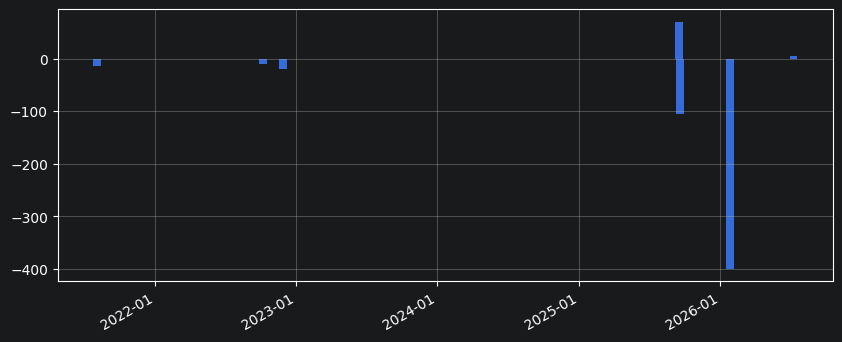

In [13]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(
    p2p_data['date'],
    p2p_data['amount'],
    width=20,  # width in days
)

ax.grid(True)
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

fig.autofmt_xdate()

In [14]:
data.describe().round(2)

,net_amount,amount,asset_price,asset_amount,fee
count,770.00,770.00,619.00,770.00,767.00
mean,0.06,0.07,3965.75,0.14,-0.01
std,36.59,36.59,15751.74,0.32,0.05
min,-400.00,-400.00,2.22,0.00,-0.50
25%,-10.00,-10.00,58.04,0.01,0.00
50%,-10.00,-10.00,127.25,0.05,0.00
75%,-0.25,-0.24,299.46,0.13,0.00
max,200.00,200.00,80346.14,4.51,0.00


In [15]:
data.nunique().sort_values(ascending=False)

date            612
asset_price     610
asset_amount    606
notes           435
asset_type      180
amount           64
net_amount       63
trans_type       10
trans_id          8
fee               7
name_trans        6
account           5
status            2
currency          1
dtype: int64

In [16]:
data['trans_type'].fillna('NA').value_counts()

trans_type
Stock Buy                    535
Deposits                      71
Stock Dividends               57
Stock Sell                    50
Bitcoin Buy                   24
Savings Internal Transfer     12
Bitcoin Sell                  10
P2P                            7
Account Notifications          3
Withdrawal                     1
Name: count, dtype: int64

In [17]:
(data
 .assign(amount=np.abs(data['amount']))
 .groupby('trans_type')
 ['amount'].describe()
 .drop('std', axis=1)
 .round(2)
 .assign(count=lambda x: x['count'].astype(int))
 .sort_values('count', ascending=False))

,count,mean,min,25%,50%,75%,max
trans_type,,,,,,,
Stock Buy,535,10.37,1.00,10.00,10.00,10.00,50.00
Deposits,71,89.24,1.00,75.00,100.00,100.00,200.00
Stock Dividends,57,0.11,0.01,0.04,0.08,0.16,0.36
Stock Sell,50,10.70,3.00,8.10,10.00,10.08,20.89
Bitcoin Buy,24,10.29,0.98,4.90,9.80,9.80,24.50
Savings Internal Transfer,12,54.17,50.00,50.00,50.00,50.00,100.00
Bitcoin Sell,10,11.90,5.00,9.25,10.00,17.50,20.00
P2P,7,89.29,5.00,12.50,20.00,87.50,400.00
Account Notifications,3,0.00,0.00,0.00,0.00,0.00,0.00


In [18]:
data['asset_type'].value_counts().head(25)

asset_type
BTC      34
XYZ      16
JPM      14
ORCL     14
AMZN     12
WFC      12
META     12
DELL     10
NFLX     10
V        10
MCD      10
PZZA     10
GOOGL     9
VONV      9
DOW       8
MSFT      8
GOOG      8
UBER      8
DAL       7
VGLT      7
INTU      7
VOO       7
VMBS      7
FISV      7
HOOD      7
Name: count, dtype: int64

Text(0, 0.5, 'Count')

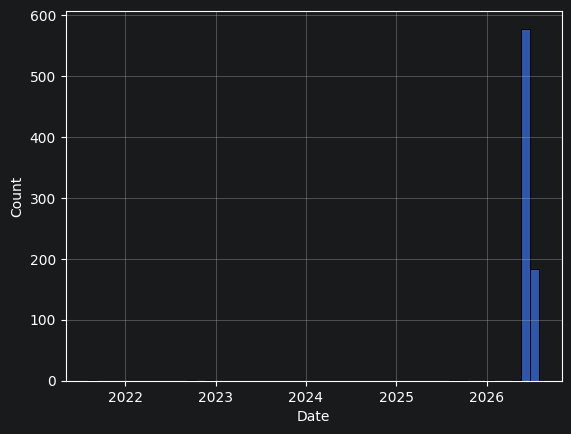

In [19]:
sns.histplot(data=data, x='date', bins=50)

plt.grid()
plt.xlabel('Date')
plt.ylabel('Count')

In [20]:
data['date'].dt.date.quantile([0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]).to_frame().T

,0.01,0.05,0.10,0.25,0.50,0.75,0.90,0.95,0.99
date,2026-05-20,2026-05-27,2026-05-30,2026-06-03,2026-06-04,2026-06-22,2026-07-10,2026-07-16,2026-07-27


In [21]:
(data
 .groupby('asset_type')
 ['amount']
 .apply(tuple)
 .to_frame()
 .assign(number=lambda df: df['amount'].apply(len))
 .assign(total=lambda df: df['amount'].apply(sum))
 .assign(amounts=lambda df: df['amount'].apply(frozenset).apply(sorted).apply(tuple))
 .drop(columns=['amount'])
 .assign(uniq_amounts=lambda df: df['amounts'].apply(len))
 .sort_values(by='number', ascending=False)
 .head(25)
 )

,number,total,amounts,uniq_amounts
asset_type,,,,
BTC,34,-127.96,"(-24.5, -9.8, -4.9, -0.98, 5.0, 9.0, 10.0, 20.0)",8
XYZ,16,-201.00,"(-50.0, -25.0, -20.0, -10.0, -5.0, -1.0, 10.0)",7
JPM,14,-79.64,"(-25.0, -10.0, -5.0, 0.36, 10.0, 20.0)",6
ORCL,14,-109.73,"(-10.0, -5.0, 0.27)",3
WFC,12,-56.00,"(-25.0, -10.0, -5.0, -1.0, 10.0, 20.0)",6
META,12,-85.95,"(-10.0, -5.0, -1.0, 0.05)",4
AMZN,12,-221.00,"(-50.0, -25.0, -10.0, -1.0)",4
MCD,10,-99.80,"(-25.0, -10.0, -5.0, 0.2)",4
V,10,-81.00,"(-25.0, -20.0, -10.0, -5.0, -1.0, 20.0)",6


In [22]:
data['currency'].value_counts()

currency
USD    770
Name: count, dtype: int64

In [23]:
data['trans_type'].value_counts()

trans_type
Stock Buy                    535
Deposits                      71
Stock Dividends               57
Stock Sell                    50
Bitcoin Buy                   24
Savings Internal Transfer     12
Bitcoin Sell                  10
P2P                            7
Account Notifications          3
Withdrawal                     1
Name: count, dtype: int64

In [24]:
top_assets = (
    data
    .pivot_table(index='asset_type', columns='trans_type', aggfunc='count',
                 values='net_amount', fill_value=0,
                 margins=True, margins_name='total')
    .sort_values(by='total', ascending=False)
    .head(40)
)
top_assets

trans_type,Bitcoin Buy,Bitcoin Sell,Stock Buy,Stock Dividends,Stock Sell,total
asset_type,,,,,,
total,24,10,535,57,50,676
BTC,24,10,0,0,0,34
XYZ,0,0,15,0,1,16
ORCL,0,0,13,1,0,14
JPM,0,0,11,1,2,14
WFC,0,0,10,0,2,12
META,0,0,11,1,0,12
AMZN,0,0,12,0,0,12
V,0,0,9,0,1,10


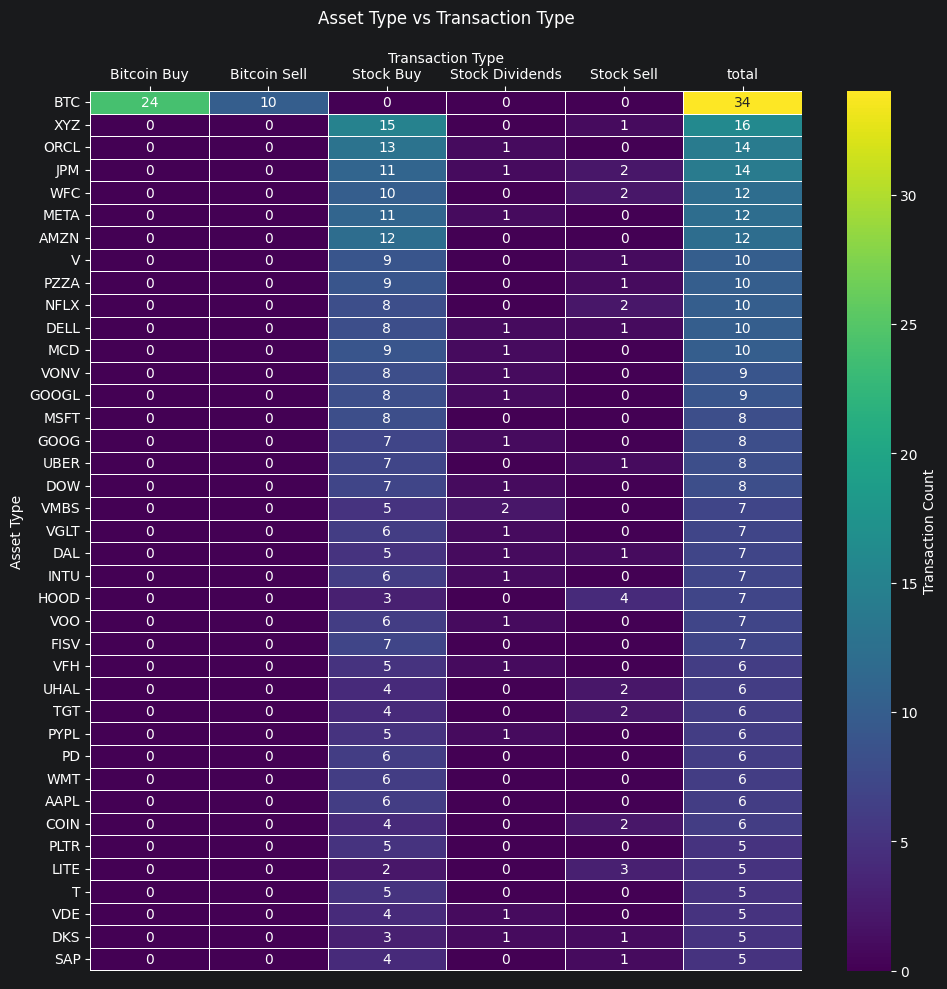

In [25]:
top_assets_heat = top_assets.drop(index='total', errors='ignore')

fig, ax = plt.subplots(figsize=(10, 10))

sns.heatmap(
    top_assets_heat,
    annot=True,
    fmt='g',
    cmap='viridis',
    linewidths=0.5,
    cbar_kws={'label': 'Transaction Count'},
    ax=ax,
)

ax.set_title('Asset Type vs Transaction Type', pad=20)
ax.set_ylabel('Asset Type', rotation=90)
ax.set_xlabel('Transaction Type', rotation=0)

ax.xaxis.tick_top()
ax.xaxis.set_label_position('top')

plt.tight_layout()


In [26]:
data_btc = data[data['asset_type'] == 'BTC']
data_btc.head()

,date,net_amount,amount,asset_price,asset_amount,fee,asset_type,trans_type,currency,trans_id,account,status,notes,name_trans
42,2026-07-16 13:31:06+00:00,8.82,9.0,63792.03,0.000141,-0.18,BTC,Bitcoin Sell,USD,NaN,Cash Balance,COMPLETE,sale of BTC 0.00014108,NaN
66,2026-07-11 11:26:39+00:00,9.80,10.0,63645.54,0.000157,-0.20,BTC,Bitcoin Sell,USD,NaN,Cash Balance,COMPLETE,sale of BTC 0.00015712,NaN
72,2026-07-10 14:02:46+00:00,9.80,10.0,63970.87,0.000156,-0.20,BTC,Bitcoin Sell,USD,NaN,Cash Balance,COMPLETE,sale of BTC 0.00015632,NaN
93,2026-07-06 16:44:23+00:00,9.80,10.0,63170.74,0.000158,-0.20,BTC,Bitcoin Sell,USD,NaN,Cash Balance,COMPLETE,sale of BTC 0.00015830,NaN
105,2026-07-02 17:10:19+00:00,19.60,20.0,61217.07,0.000327,-0.40,BTC,Bitcoin Sell,USD,NaN,Cash Balance,COMPLETE,sale of BTC 0.00032671,NaN


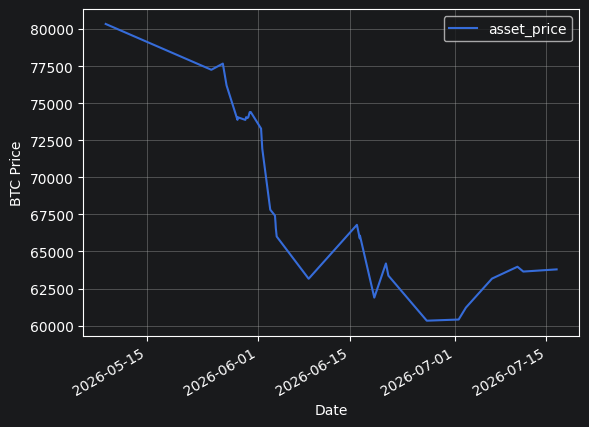

In [27]:
data_btc.plot.line(x='date', y='asset_price')
plt.xlabel('Date')
plt.ylabel('BTC Price')
plt.grid()

In [28]:
data_btc['trans_type'].value_counts()

trans_type
Bitcoin Buy     24
Bitcoin Sell    10
Name: count, dtype: int64

In [29]:
data_btc.pivot_table(index='trans_type', aggfunc='sum', values='net_amount')

,net_amount
trans_type,
Bitcoin Buy,-252.00
Bitcoin Sell,116.62


In [30]:
data_btc['net_amount'].sum()

np.float64(-135.38)

In [31]:
trans_btc = data_btc.pivot_table(index='trans_type', aggfunc='sum', values='asset_amount')['asset_amount']
trans_btc

trans_type
Bitcoin Buy     0.003420
Bitcoin Sell    0.001889
Name: asset_amount, dtype: float64

In [32]:
data_btc['asset_amount'].sum()

np.float64(0.005308329999999999)

In [33]:
btc_amount = trans_btc['Bitcoin Buy'] - trans_btc['Bitcoin Sell']
btc_amount

np.float64(0.00153091)

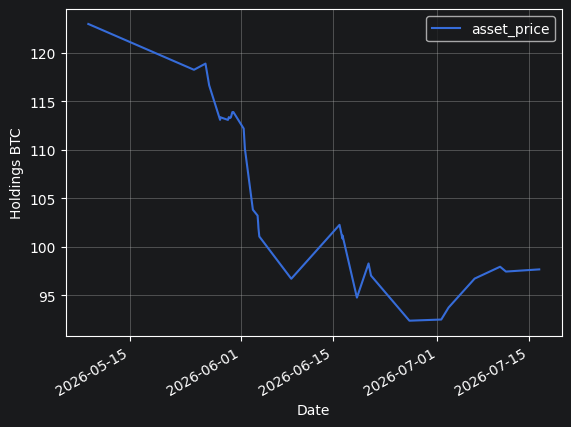

In [34]:
data_btc.assign(asset_price=lambda x: btc_amount * x['asset_price']).plot.line(x='date', y='asset_price')
plt.xlabel('Date')
plt.ylabel('Holdings BTC')
plt.grid()

In [35]:
data_btc['asset_price'] * data_btc['asset_amount']

42      8.999780
66      9.999987
72      9.999926
93      9.999928
105    20.000229
133     9.800290
170     4.900090
225    10.000046
227     4.899747
236    19.999846
318     5.000156
319     4.999899
322     4.900240
358    19.999798
438     9.799846
465     9.800287
489     0.980144
586     9.800221
597     0.979969
614     9.799652
672     4.900136
674     9.799865
677     4.900112
678     9.799903
682     9.799965
686    24.500200
693    24.499951
697    24.500084
716     9.799731
720     9.800031
743    24.499991
760     9.799898
761     4.900356
762     9.799819
dtype: float64

In [36]:
data_xyz = data[data['asset_type'] == 'XYZ']
data_xyz

,date,net_amount,amount,asset_price,asset_amount,fee,asset_type,trans_type,currency,trans_id,account,status,notes,name_trans
13,2026-07-27 13:30:03+00:00,-10.0,-10.0,78.88,0.12677,0.0,XYZ,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$10 Purchase of Block,NaN
21,2026-07-21 13:33:10+00:00,-10.0,-10.0,79.31,0.12608,0.0,XYZ,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$10 Purchase of Block,NaN
88,2026-07-08 17:05:18+00:00,-10.0,-10.0,76.07,0.13145,0.0,XYZ,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$10 Purchase of Block,NaN
169,2026-06-26 17:43:48+00:00,-10.0,-10.0,77.24,0.12946,0.0,XYZ,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$10 Purchase of Block,NaN
198,2026-06-22 13:33:13+00:00,10.0,10.0,74.28,0.13462,0.0,XYZ,Stock Sell,USD,NaN,Cash Balance,COMPLETE,$10 Sale of Block,NaN
280,2026-06-16 13:31:47+00:00,-5.0,-5.0,74.95,0.06671,0.0,XYZ,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$5 Purchase of Block,NaN
325,2026-06-15 13:32:07+00:00,-10.0,-10.0,72.26,0.13838,0.0,XYZ,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$10 Purchase of Block,NaN
373,2026-06-04 13:31:36+00:00,-20.0,-20.0,70.84,0.28232,0.0,XYZ,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$20 Purchase of Block,NaN
449,2026-06-03 19:22:37+00:00,-10.0,-10.0,69.87,0.14312,0.0,XYZ,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$10 Purchase of Block,NaN
461,2026-06-03 16:57:03+00:00,-10.0,-10.0,69.67,0.14353,0.0,XYZ,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$10 Purchase of Block,NaN


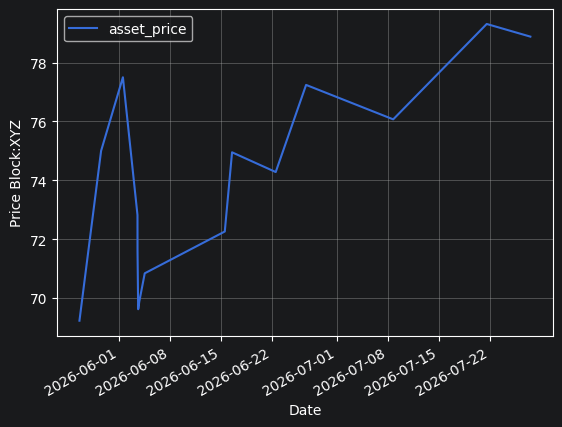

In [37]:
data_xyz.plot.line(x='date', y='asset_price')
plt.xlabel('Date')
plt.ylabel('Price Block:XYZ')
plt.grid()

In [38]:
asset_count = data.groupby('asset_type')['amount'].count().sort_values(ascending=False)
asset_count

asset_type
BTC     34
XYZ     16
JPM     14
ORCL    14
WFC     12
        ..
RIVN     1
SHOP     1
SLAB     1
SNAP     1
ZG       1
Name: amount, Length: 180, dtype: int64

In [39]:
asset_price = data.pivot_table(index='date', columns='asset_type', aggfunc='sum', values='asset_price').bfill(axis=0)
asset_price.head()

asset_type,AAPL,ABNB,ACN,ADBE,ADP,AFRM,ALKT,ALLY,AMAT,AMD,...,WEN,WFC,WMG,WMT,XLB,XYZ,YUM,YUMC,Z,ZG
date,,,,,,,,,,,,,,,,,,,,,
2026-05-08 16:42:34+00:00,307.3,133.22,183.16,270.0,223.99,65.83,18.43,41.48,445.96,543.37,...,6.28,77.41,30.62,118.97,51.35,69.23,149.54,42.9,36.36,36.25
2026-05-24 19:57:02+00:00,307.3,133.22,183.16,270.0,223.99,65.83,18.43,41.48,445.96,543.37,...,6.28,77.41,30.62,118.97,51.35,69.23,149.54,42.9,36.36,36.25
2026-05-26 14:06:39+00:00,307.3,133.22,183.16,270.0,223.99,65.83,18.43,41.48,445.96,543.37,...,6.28,77.41,30.62,118.97,51.35,69.23,149.54,42.9,36.36,36.25
2026-05-26 14:09:07+00:00,307.3,133.22,183.16,270.0,223.99,65.83,18.43,41.48,445.96,543.37,...,6.28,77.41,30.62,118.97,51.35,69.23,149.54,42.9,36.36,36.25
2026-05-27 03:38:54+00:00,307.3,133.22,183.16,270.0,223.99,65.83,18.43,41.48,445.96,543.37,...,6.28,77.41,30.62,118.97,51.35,75.00,149.54,42.9,36.36,36.25


In [40]:
data['asset_amount'].describe()

count    770.000000
mean       0.136966
std        0.316502
min        0.000000
25%        0.006018
50%        0.045845
75%        0.129282
max        4.509170
Name: asset_amount, dtype: float64

In [41]:
data[data['asset_type'] == 'ADP']

,date,net_amount,amount,asset_price,asset_amount,fee,asset_type,trans_type,currency,trans_id,account,status,notes,name_trans
162,2026-07-01 04:00:00+00:00,0.15,0.15,NaN,0.00000,0.0,ADP,Stock Dividends,USD,NaN,Cash Balance,COMPLETE,$0.15 Dividend from Automatic Data Processing,NaN
235,2026-06-18 17:14:10+00:00,-10.00,-10.00,217.48,0.04598,0.0,ADP,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$10 Purchase of Automatic Data Processing,NaN
499,2026-06-03 15:08:22+00:00,-10.00,-10.00,226.23,0.04420,0.0,ADP,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$10 Purchase of Automatic Data Processing,NaN
624,2026-06-01 13:30:28+00:00,-10.00,-10.00,223.99,0.04464,0.0,ADP,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$10 Purchase of Automatic Data Processing,NaN


In [42]:
stock_amount_direction = {'Stock Sell': -1, 'Stock Buy': 1}
asset_holding_time = (
    data
    [data['trans_type'].isin(stock_amount_direction.keys())]
    .assign(stock_direction=lambda x: x['trans_type'].map(stock_amount_direction))
    .assign(asset_amount=lambda x: x['asset_amount'] * x['stock_direction'])
    .pivot_table(index='date', columns='asset_type', aggfunc='sum', values='asset_amount')
    .fillna(0)
    .cumsum(axis=0)
    .mul(asset_price, axis=1)
    .dropna(how='all')
    .ffill(axis=0)
    .sort_index()
)
asset_holding_time.sample(10, random_state=0xCAFE).sort_index()

asset_type,AAPL,ABNB,ACN,ADBE,ADP,AFRM,ALKT,ALLY,AMAT,AMD,...,WEN,WFC,WMG,WMT,XLB,XYZ,YUM,YUMC,Z,ZG
date,,,,,,,,,,,,,,,,,,,,,
2026-05-27 13:30:09+00:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000e+00,0.000000,0.000000,0.000000,0.0,21.666750,0.000000,0.000000,0.000000,0.000000
2026-06-03 13:34:50+00:00,20.147721,9.999493,9.010079,8.379889,10.098907,0.000000,20.893584,0.000000,14.039852,0.000000,...,0.000000e+00,31.527923,9.686363,19.992722,0.0,92.484257,0.000000,9.953370,0.000000,0.000000
2026-06-03 19:46:16+00:00,20.147721,9.999493,9.010079,8.379889,19.320923,9.999577,20.893584,0.000000,14.039852,20.071824,...,0.000000e+00,63.030258,18.724670,27.762524,0.0,131.892037,30.191289,9.953370,0.000000,0.000000
2026-06-04 13:30:03+00:00,20.147721,9.999493,9.010079,8.379889,19.320923,9.999577,20.893584,0.000000,14.039852,20.071824,...,0.000000e+00,63.030258,18.724670,27.762524,0.0,131.892037,30.191289,9.953370,9.999727,9.999925
2026-06-16 15:44:16+00:00,28.691891,9.999493,11.181242,8.379889,19.320923,9.999577,20.893584,11.051107,14.039852,20.071824,...,0.000000e+00,81.303113,18.724670,27.762524,0.0,174.501547,30.191289,9.953370,9.999727,9.999925
2026-06-16 15:51:44+00:00,28.691891,9.999493,11.181242,8.379889,19.320923,9.999577,20.893584,11.051107,14.039852,20.071824,...,0.000000e+00,81.303113,18.724670,27.762524,0.0,174.501547,30.191289,9.953370,9.999727,9.999925
2026-06-18 14:10:06+00:00,28.691891,9.999493,11.181242,8.379889,19.320923,9.999577,20.893584,11.051107,14.039852,20.071824,...,0.000000e+00,81.303113,23.724046,27.762524,0.0,174.501547,30.191289,9.953370,9.999727,9.999925
2026-07-16 13:30:07+00:00,61.309073,9.999493,16.180396,18.377823,0.000000,9.999577,0.000000,21.050186,9.042617,30.069556,...,6.113515e+00,63.199466,23.724046,59.104053,0.0,196.334284,52.997013,19.954137,9.999727,9.999925
2026-07-17 13:30:06+00:00,61.309073,9.999493,16.180396,18.377823,0.000000,9.999577,0.000000,21.050186,9.042617,30.069556,...,-8.337775e-16,63.199466,23.724046,59.104053,0.0,196.334284,52.997013,19.954137,9.999727,9.999925


In [43]:
asset_holding_time.iloc[-1].sum(axis=0)

np.float64(3905.8035029000002)

In [44]:
asset_holding_time_last = asset_holding_time.iloc[-1].sort_values(ascending=False)
asset_holding_time_last.head()

asset_type
XYZ     215.214614
AMZN    212.311076
MCD      98.010046
UBER     96.165081
META     93.747478
Name: 2026-07-29 13:30:01+00:00, dtype: float64

In [45]:
asset_holding_time_last.tail()

asset_type
RUN    0.000000e+00
VDC    0.000000e+00
DKS    0.000000e+00
WEN   -8.337775e-16
BTC             NaN
Name: 2026-07-29 13:30:01+00:00, dtype: float64

In [46]:
zero_assets = asset_holding_time_last[asset_holding_time_last == 0.0].sort_index().index
zero_assets

Index(['ADP', 'ALKT', 'AMX', 'AVGO', 'BBEU', 'BNDX', 'CRM', 'CSCO', 'CXSE',
       'DAL', 'DELL', 'DIS', 'DKS', 'EMB', 'FIS', 'GAP', 'GM', 'GSLC', 'HPQ',
       'ILMN', 'INTU', 'JPM', 'KO', 'KWEB', 'LECO', 'NOBL', 'NTAP', 'NVDA',
       'ORCL', 'OWL', 'OXY', 'POR', 'PSKY', 'QCOM', 'RUM', 'RUN', 'TSM', 'VBR',
       'VDC', 'VFH', 'VHT', 'VMBS', 'VNQ', 'VONG', 'VSS', 'VTEB', 'XLB'],
      dtype='str', name='asset_type')

In [47]:
data[data['asset_type'].isin(zero_assets)][['asset_type', 'notes']].sort_values('asset_type')

,asset_type,notes
624,ADP,$10 Purchase of Automatic Data Processing
499,ADP,$10 Purchase of Automatic Data Processing
235,ADP,$10 Purchase of Automatic Data Processing
162,ADP,$0.15 Dividend from Automatic Data Processing
669,ALKT,$10 Purchase of Alkami Technology
...,...,...
257,VTEB,$5 Purchase of Vanguard Tax-Exempt Bond ETF
102,VTEB,$0.04 Dividend from Vanguard Tax-Exempt Bond ETF
661,VTEB,$10 Purchase of Vanguard Tax-Exempt Bond ETF
583,XLB,$10 Purchase of Materials Select Sector SPDR


In [48]:
asset_price_rel = asset_holding_time.div(asset_holding_time.iloc[-1].sum(axis=0))
asset_price_rel.tail(5)

asset_type,AAPL,ABNB,ACN,ADBE,ADP,AFRM,ALKT,ALLY,AMAT,AMD,...,WEN,WFC,WMG,WMT,XLB,XYZ,YUM,YUMC,Z,ZG
date,,,,,,,,,,,,,,,,,,,,,
2026-07-27 13:30:26+00:00,0.015697,0.00256,0.004143,0.004705,0.0,0.00256,0.0,0.005389,0.002315,0.007699,...,-2.134714e-19,0.016181,0.006074,0.015132,0.0,0.055101,0.013569,0.005109,0.00256,0.00256
2026-07-27 13:31:29+00:00,0.015697,0.00256,0.004143,0.004705,0.0,0.00256,0.0,0.005389,0.002315,0.007699,...,-2.134714e-19,0.016181,0.006074,0.015132,0.0,0.055101,0.013569,0.005109,0.00256,0.00256
2026-07-27 19:21:54+00:00,0.015697,0.00256,0.004143,0.004705,0.0,0.00256,0.0,0.005389,0.002315,0.007699,...,-2.134714e-19,0.016181,0.006074,0.015132,0.0,0.055101,0.013569,0.005109,0.00256,0.00256
2026-07-29 13:30:00+00:00,0.015697,0.00256,0.004143,0.004705,0.0,0.00256,0.0,0.005389,0.002315,0.007699,...,-2.134714e-19,0.016181,0.006074,0.015132,0.0,0.055101,0.013569,0.005109,0.00256,0.00256
2026-07-29 13:30:01+00:00,0.015697,0.00256,0.004143,0.004705,0.0,0.00256,0.0,0.005389,0.002315,0.007699,...,-2.134714e-19,0.016181,0.006074,0.015132,0.0,0.055101,0.013569,0.005109,0.00256,0.00256


In [49]:
asset_price_rel.iloc[-1].describe()

count    1.790000e+02
mean     5.586592e-03
std      7.645324e-03
min     -2.134714e-19
25%      0.000000e+00
50%      3.807201e-03
75%      6.645593e-03
max      5.510124e-02
Name: 2026-07-29 13:30:01+00:00, dtype: float64

In [50]:
asset_price_rel_last = asset_price_rel.iloc[-1].sort_values(ascending=False)
asset_price_rel_last.head()

asset_type
XYZ     0.055101
AMZN    0.054358
MCD     0.025093
UBER    0.024621
META    0.024002
Name: 2026-07-29 13:30:01+00:00, dtype: float64

In [51]:
asset_price_rel_last.tail()

asset_type
RUN    0.000000e+00
VDC    0.000000e+00
DKS    0.000000e+00
WEN   -2.134714e-19
BTC             NaN
Name: 2026-07-29 13:30:01+00:00, dtype: float64

<Axes: ylabel='Frequency'>

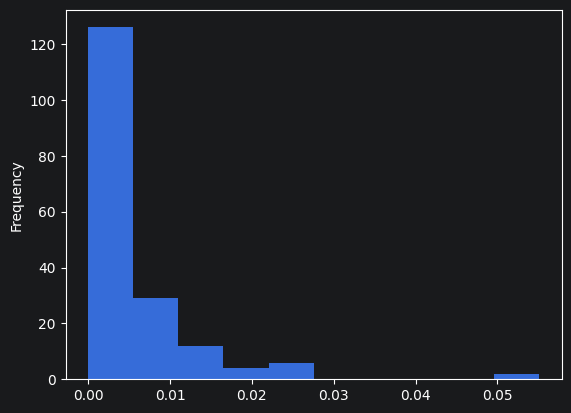

In [52]:
asset_price_rel_last.plot.hist()

In [53]:
asset_price_rel.tail(5)

asset_type,AAPL,ABNB,ACN,ADBE,ADP,AFRM,ALKT,ALLY,AMAT,AMD,...,WEN,WFC,WMG,WMT,XLB,XYZ,YUM,YUMC,Z,ZG
date,,,,,,,,,,,,,,,,,,,,,
2026-07-27 13:30:26+00:00,0.015697,0.00256,0.004143,0.004705,0.0,0.00256,0.0,0.005389,0.002315,0.007699,...,-2.134714e-19,0.016181,0.006074,0.015132,0.0,0.055101,0.013569,0.005109,0.00256,0.00256
2026-07-27 13:31:29+00:00,0.015697,0.00256,0.004143,0.004705,0.0,0.00256,0.0,0.005389,0.002315,0.007699,...,-2.134714e-19,0.016181,0.006074,0.015132,0.0,0.055101,0.013569,0.005109,0.00256,0.00256
2026-07-27 19:21:54+00:00,0.015697,0.00256,0.004143,0.004705,0.0,0.00256,0.0,0.005389,0.002315,0.007699,...,-2.134714e-19,0.016181,0.006074,0.015132,0.0,0.055101,0.013569,0.005109,0.00256,0.00256
2026-07-29 13:30:00+00:00,0.015697,0.00256,0.004143,0.004705,0.0,0.00256,0.0,0.005389,0.002315,0.007699,...,-2.134714e-19,0.016181,0.006074,0.015132,0.0,0.055101,0.013569,0.005109,0.00256,0.00256
2026-07-29 13:30:01+00:00,0.015697,0.00256,0.004143,0.004705,0.0,0.00256,0.0,0.005389,0.002315,0.007699,...,-2.134714e-19,0.016181,0.006074,0.015132,0.0,0.055101,0.013569,0.005109,0.00256,0.00256


In [54]:
asset_price_time = (
    data
    .pivot_table(index='date', columns='asset_type', aggfunc='median', values='asset_price')
    .dropna(how='all')
)
asset_price_time.sample(10, random_state=0xCAFE)

asset_type,AAPL,ABNB,ACN,ADBE,ADP,AFRM,ALKT,ALLY,AMAT,AMD,...,WEN,WFC,WMG,WMT,XLB,XYZ,YUM,YUMC,Z,ZG
date,,,,,,,,,,,,,,,,,,,,,
2026-06-16 13:30:13+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-03 19:35:58+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-07-17 13:30:28+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-07-10 13:31:04+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-03 15:17:56+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-07-10 13:31:30+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-08 16:37:07+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-03 19:24:06+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-03 19:24:53+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [55]:
asset_price_rel = asset_price_time.div(asset_price_time.bfill().iloc[0]).ffill().fillna(1)
asset_price_rel.sample(10, random_state=0xCAFE)

asset_type,AAPL,ABNB,ACN,ADBE,ADP,AFRM,ALKT,ALLY,AMAT,AMD,...,WEN,WFC,WMG,WMT,XLB,XYZ,YUM,YUMC,Z,ZG
date,,,,,,,,,,,,,,,,,,,,,
2026-06-16 13:30:13+00:00,1.018386,1.0,1.000000,1.000000,1.010000,1.0,0.954965,1.000000,1.000000,1.000000,...,1.000000,1.035138,0.968648,0.976969,1.0,1.043767,0.997325,1.000000,1.0,1.0
2026-06-03 19:35:58+00:00,1.021803,1.0,1.000000,1.000000,1.010000,1.0,0.954965,1.000000,1.000000,1.000000,...,1.000000,1.016406,0.968648,0.976969,1.0,1.009245,1.000000,1.000000,1.0,1.0
2026-07-17 13:30:28+00:00,1.017280,1.0,0.719207,0.838148,0.970936,1.0,1.020619,1.105111,1.404207,1.003791,...,1.195860,1.124661,0.921293,0.939144,1.0,1.098801,1.075766,0.995338,1.0,1.0
2026-07-10 13:31:04+00:00,1.017280,1.0,0.719207,0.838148,0.970936,1.0,1.020619,1.105111,1.404207,1.003791,...,1.342357,1.072471,0.921293,0.939144,1.0,1.098801,1.075766,0.995338,1.0,1.0
2026-06-03 15:17:56+00:00,1.021803,1.0,1.000000,1.000000,1.010000,1.0,0.954965,1.000000,1.000000,1.000000,...,1.000000,1.008655,1.000000,0.976969,1.0,1.034089,1.000000,1.000000,1.0,1.0
2026-07-10 13:31:30+00:00,1.017280,1.0,0.719207,0.838148,0.970936,1.0,1.020619,1.105111,1.404207,1.003791,...,1.342357,1.072471,0.921293,0.939144,1.0,1.098801,1.075766,0.995338,1.0,1.0
2026-06-08 16:37:07+00:00,1.021803,1.0,1.000000,1.000000,1.010000,1.0,0.954965,1.000000,1.000000,1.000000,...,1.000000,1.035138,0.968648,0.976969,1.0,1.023256,0.997325,1.000000,1.0,1.0
2026-06-03 19:24:06+00:00,1.021803,1.0,1.000000,1.000000,1.010000,1.0,0.954965,1.000000,1.000000,1.000000,...,1.000000,1.012014,0.968648,0.976969,1.0,1.009245,1.000000,1.000000,1.0,1.0
2026-06-03 19:24:53+00:00,1.021803,1.0,1.000000,1.000000,1.010000,1.0,0.954965,1.000000,1.000000,1.000000,...,1.000000,1.012014,0.968648,0.976969,1.0,1.009245,1.000000,1.000000,1.0,1.0


Text(0, 0.5, 'Relative Value of Asset Price')

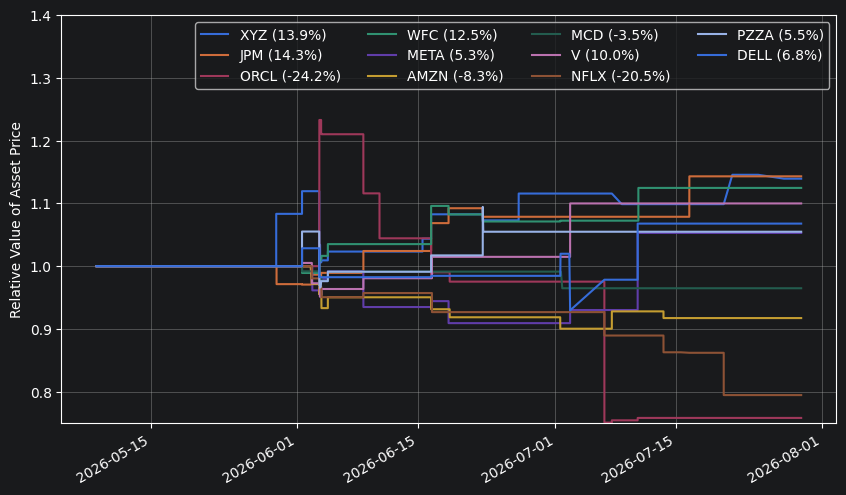

In [56]:
asset_price_rel_plot = asset_price_rel[asset_count.head(12).iloc[1::].index].copy()
asset_price_rel_plot_perc = asset_price_rel_plot.iloc[-1].sub(1).mul(100).round(1)
asset_price_rel_plot.columns = [f'{col} ({perc}%)' for col, perc in
                                zip(asset_price_rel_plot.columns, asset_price_rel_plot_perc)]
fig, ax = plt.subplots(figsize=(10, 6))
asset_price_rel_plot.plot.line(ax=ax)
plt.grid()
plt.legend(ncols=4, loc='upper right')
plt.ylim(0.75, 1.4)
plt.xlabel('')
plt.ylabel('Relative Value of Asset Price')

In [57]:
asset_price_rel['XYZ'].dropna()

date
2026-05-08 16:42:34+00:00    1.00000
2026-05-24 19:57:02+00:00    1.00000
2026-05-26 14:06:39+00:00    1.00000
2026-05-26 14:09:07+00:00    1.00000
2026-05-27 03:38:54+00:00    1.00000
                              ...   
2026-07-27 13:30:26+00:00    1.13939
2026-07-27 13:31:29+00:00    1.13939
2026-07-27 19:21:54+00:00    1.13939
2026-07-29 13:30:00+00:00    1.13939
2026-07-29 13:30:01+00:00    1.13939
Name: XYZ, Length: 491, dtype: float64

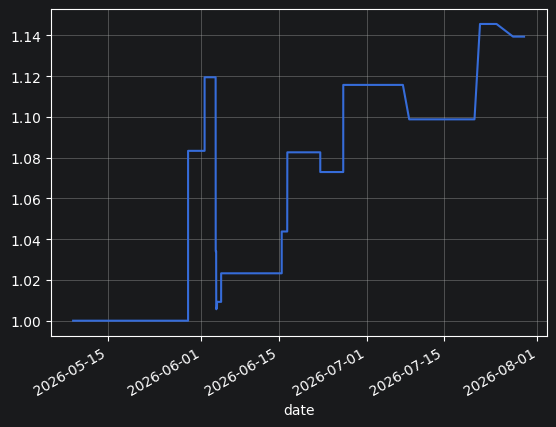

In [58]:
asset_price_rel['XYZ'].dropna().plot.line()
plt.grid()


In [59]:
div_data = (
    data[data['trans_type'] == 'Stock Dividends']
    .drop(columns=['asset_amount', 'fee', 'asset_price', 'trans_id', 'name_trans', 'account', 'currency', 'status',
                   'trans_type', 'net_amount'])
    .assign(date=lambda x: x['date'].dt.date)
    .sort_values('date', ascending=False)
)
div_data

,date,amount,asset_type,notes
0,2026-07-31,0.17,DELL,$0.17 Dividend from Dell Technologies
1,2026-07-31,0.36,JPM,$0.36 Dividend from JPMorgan Chase
2,2026-07-30,0.11,DAL,$0.11 Dividend from Delta Air Lines
5,2026-07-29,0.08,NTAP,$0.08 Dividend from NetApp
6,2026-07-29,0.12,GAP,$0.12 Dividend from Gap
17,2026-07-24,0.27,ORCL,$0.27 Dividend from Oracle
18,2026-07-22,0.30,AMX,$0.30 Dividend from America Movil
19,2026-07-22,0.07,CSCO,$0.07 Dividend from Cisco Systems
20,2026-07-22,0.15,DIS,$0.15 Dividend from Disney
30,2026-07-17,0.22,INTU,$0.22 Dividend from Intuit


In [60]:
div_data['amount'].sum()

np.float64(6.19)

In [61]:
div_data.sort_values('amount', ascending=False)

,date,amount,asset_type,notes
1,2026-07-31,0.36,JPM,$0.36 Dividend from JPMorgan Chase
174,2026-06-26,0.30,VFH,$0.30 Dividend from Vanguard Financials ETF
18,2026-07-22,0.30,AMX,$0.30 Dividend from America Movil
159,2026-07-01,0.27,HPQ,$0.27 Dividend from Hewlett Packard
17,2026-07-24,0.27,ORCL,$0.27 Dividend from Oracle
181,2026-06-25,0.26,BBEU,$0.26 Dividend from JPMorgan BetaBuilders Euro...
30,2026-07-17,0.22,INTU,$0.22 Dividend from Intuit
177,2026-06-26,0.20,VDE,$0.20 Dividend from Energy ETF Vanguard
320,2026-06-16,0.20,MCD,$0.20 Dividend from McDonald's
171,2026-06-26,0.18,VNQ,$0.18 Dividend from Vanguard Real Estate ETF


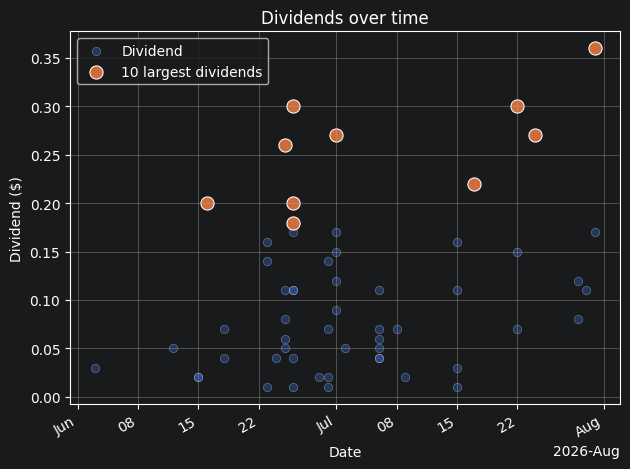

In [62]:
d = div_data.copy()
d["Date"] = pd.to_datetime(d["date"])
d = d.sort_values("date")

top10 = d.nlargest(10, "amount")

ax = sns.scatterplot(
    data=d,
    x="date",
    y="amount",
    alpha=0.35,
    label="Dividend",
)

sns.scatterplot(
    data=top10,
    x="date",
    y="amount",
    s=90,
    ax=ax,
    label="10 largest dividends",
)

for _, r in top10.iterrows():
    ax.annotate(
        r["asset_type"],
        (r["date"], r["date"]),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=8,
    )

ax.set_title("Dividends over time")
ax.set_xlabel("Date")
ax.set_ylabel("Dividend ($)")

ax.xaxis.set_major_locator(mdates.AutoDateLocator())
ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(ax.xaxis.get_major_locator()))

ax.legend()
plt.grid()
plt.xticks(rotation=30, ha="right")
plt.tight_layout()

In [63]:
vanguard_data = (
    data[
        data['notes']
        .str.lower()
        .str.contains('vanguard')
    ]
    [['date', 'net_amount', 'asset_price', 'notes', 'asset_type']]
)
vanguard_data.sample(10, random_state=0xCAFE)


,date,net_amount,asset_price,notes,asset_type
653,2026-06-01 13:30:11+00:00,-10.00,125.85,$10 Purchase of Vanguard Financials ETF,VFH
595,2026-06-03 04:00:00+00:00,0.03,NaN,$0.03 Dividend from Vanguard Mortgage-Backed S...,VMBS
99,2026-07-06 04:00:00+00:00,0.04,NaN,$0.04 Dividend from Vanguard Intermediate Term...,BIV
144,2026-07-01 14:17:44+00:00,-10.00,686.18,$10 Purchase of Vanguard S&P 500 ETF,VOO
174,2026-06-26 04:00:00+00:00,0.30,NaN,$0.30 Dividend from Vanguard Financials ETF,VFH
254,2026-06-18 14:09:00+00:00,-5.00,687.48,$5 Purchase of Vanguard S&P 500 ETF,VOO
502,2026-06-03 15:06:50+00:00,-10.00,159.33,$10 Purchase of Vanguard FTSE All World ex US ...,VSS
475,2026-06-03 15:49:42+00:00,-10.00,124.12,$10 Purchase of Vanguard Financials ETF,VFH
78,2026-07-10 13:30:12+00:00,-5.00,691.29,$5 Purchase of Vanguard S&P 500 ETF,VOO
143,2026-07-01 14:18:01+00:00,-10.00,106.84,$10 Purchase of Vanguard Russell 1000 Value ETF,VONV


In [64]:
vanguard_trans_count = vanguard_data['asset_type'].value_counts()
vanguard_trans_count

asset_type
VONV    9
VGLT    7
VOO     7
VMBS    7
VFH     6
VDE     5
BIV     4
VCR     4
VNQ     4
VHT     4
VSS     4
BNDX    3
VTEB    3
VBR     3
VDC     3
VONG    3
VGSH    2
BND     2
BSV     2
VCSH    1
VGT     1
Name: count, dtype: int64

In [65]:
vanguard_note_name = (
    vanguard_data['notes']
    .pipe(lambda x: x[x.str.contains('Purchase')])
    .str.replace('.*Purchase of', '', regex=True)
)
vanguard_data_asset_names = (
    vanguard_data
    .assign(name=vanguard_note_name)
    .drop(columns=['notes'])
)
vanguard_data_asset_names.sample(10, random_state=0xCAFE)

,date,net_amount,asset_price,asset_type,name
653,2026-06-01 13:30:11+00:00,-10.00,125.85,VFH,Vanguard Financials ETF
595,2026-06-03 04:00:00+00:00,0.03,NaN,VMBS,NaN
99,2026-07-06 04:00:00+00:00,0.04,NaN,BIV,NaN
144,2026-07-01 14:17:44+00:00,-10.00,686.18,VOO,Vanguard S&P 500 ETF
174,2026-06-26 04:00:00+00:00,0.30,NaN,VFH,NaN
254,2026-06-18 14:09:00+00:00,-5.00,687.48,VOO,Vanguard S&P 500 ETF
502,2026-06-03 15:06:50+00:00,-10.00,159.33,VSS,Vanguard FTSE All World ex US Small Cap ETF
475,2026-06-03 15:49:42+00:00,-10.00,124.12,VFH,Vanguard Financials ETF
78,2026-07-10 13:30:12+00:00,-5.00,691.29,VOO,Vanguard S&P 500 ETF
143,2026-07-01 14:18:01+00:00,-10.00,106.84,VONV,Vanguard Russell 1000 Value ETF


In [66]:
vanguard_data_asset_names_trans_count = (
    vanguard_data_asset_names
    .groupby(['asset_type', 'name'])
    ['date']
    .count()
    .sort_values(ascending=False)
)
vanguard_data_asset_names_trans_count

asset_type  name                                       
VONV        Vanguard Russell 1000 Value ETF                8
VGLT        Vanguard Long-Treasury ETF                     6
VOO         Vanguard S&P 500 ETF                           6
VMBS        Vanguard Mortgage-Backed Securities ETF        5
VFH         Vanguard Financials ETF                        5
VDE         Energy ETF Vanguard                            4
VSS         Vanguard FTSE All World ex US Small Cap ETF    3
VHT         Vanguard Health Care ETF                       3
BIV         Vanguard Intermediate Term Bond ETF            3
VCR         Vanguard Consumer Discretionary ETF            3
VDC         Vanguard Consumer Staples Index Fund ETF       2
BND         Vanguard Total Bond Market ETF                 2
VGSH        Vanguard Short-Term Treasury ETF               2
VNQ         Vanguard Real Estate ETF                       2
VONG        Vanguard Russell 1000 Growth ETF               2
VBR         Small Cap Value E

In [67]:
vanguard_asset_price_time = asset_holding_time = (
    vanguard_data
    .pivot_table(index='date', columns='asset_type', aggfunc='median', values='asset_price')
    [vanguard_trans_count.index]
    .dropna(how='all')
)
vanguard_asset_price_time

asset_type,VONV,VGLT,VOO,VMBS,VFH,VDE,BIV,VCR,VNQ,VHT,...,BNDX,VTEB,VBR,VDC,VONG,VGSH,BND,BSV,VCSH,VGT
date,,,,,,,,,,,,,,,,,,,,,
2026-05-29 14:26:46+00:00,NaN,NaN,NaN,46.86,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-01 13:30:01+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,233.47,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-01 13:30:04+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,50.12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-01 13:30:06+00:00,NaN,NaN,NaN,46.56,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-01 13:30:10+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,397.97,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-07-24 13:30:12+00:00,NaN,53.33,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-07-27 13:30:22+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,58.02,NaN,NaN,NaN,NaN
2026-07-27 13:30:26+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,78.51,NaN


In [68]:
vanguard_trans_count

asset_type
VONV    9
VGLT    7
VOO     7
VMBS    7
VFH     6
VDE     5
BIV     4
VCR     4
VNQ     4
VHT     4
VSS     4
BNDX    3
VTEB    3
VBR     3
VDC     3
VONG    3
VGSH    2
BND     2
BSV     2
VCSH    1
VGT     1
Name: count, dtype: int64

Text(0, 0.5, 'Relative Value of Asset Price')

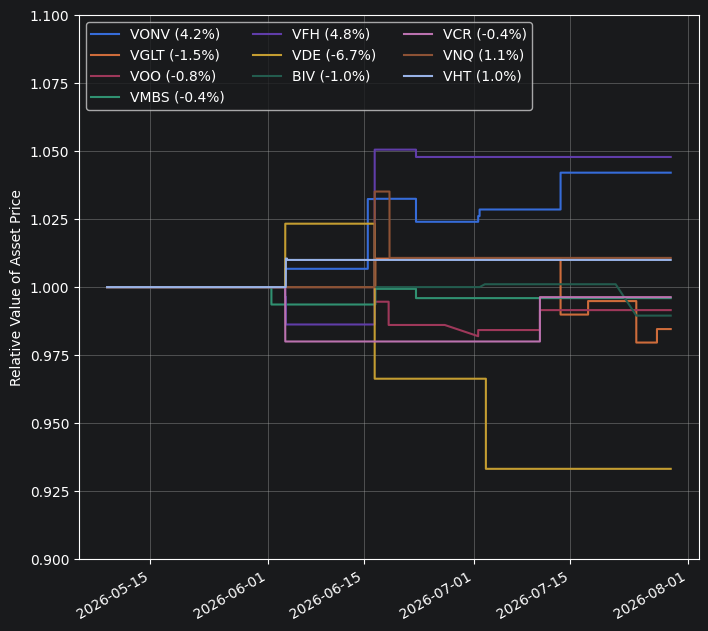

In [69]:
asset_price_rel_plot = asset_price_rel[list(vanguard_trans_count.head(10).index)].copy()
asset_price_rel_plot_perc = asset_price_rel_plot.iloc[-1].sub(1).mul(100).round(1)
asset_price_rel_plot.columns = [f'{col} ({perc}%)' for col, perc in
                                zip(asset_price_rel_plot.columns, asset_price_rel_plot_perc)]
fig, ax = plt.subplots(figsize=(8, 8))

asset_price_rel_plot.plot.line(ax=ax)
plt.grid()
plt.ylim(0.9, 1.1)
plt.legend(ncols=3, loc='upper left')
plt.xlabel('')
plt.ylabel('Relative Value of Asset Price')

In [70]:
data_deposits = data[data['trans_type'] == 'Deposits'][['date', 'net_amount', 'account', 'status', 'notes']]
data_deposits

,date,net_amount,account,status,notes
14,2026-07-26 14:27:29+00:00,100.0,Visa debit 3333,COMPLETE,Add Cash
29,2026-07-17 09:46:47+00:00,100.0,Visa debit 3333,COMPLETE,Add Cash
31,2026-07-16 22:04:59+00:00,100.0,Visa debit 3333,COMPLETE,Add Cash
54,2026-07-16 09:35:34+00:00,100.0,Visa debit 3333,COMPLETE,Add Cash
67,2026-07-10 21:11:17+00:00,100.0,Visa debit 3333,COMPLETE,Add Cash
...,...,...,...,...,...
754,2026-05-27 00:56:27+00:00,100.0,Visa debit 5895,FAILED,Add Cash
755,2026-05-27 00:56:05+00:00,10.0,Visa debit 5895,COMPLETE,Add Cash
756,2026-05-27 00:43:01+00:00,50.0,Visa debit 5895,COMPLETE,Add Cash
757,2026-05-26 21:58:29+00:00,20.0,Visa debit 5895,COMPLETE,Add Cash


In [71]:
data_deposits['net_amount'].sum()

np.float64(6335.96)

In [72]:
data_deposits['net_amount'].describe().to_frame().T

,count,mean,std,min,25%,50%,75%,max
net_amount,71.0,89.238873,47.885439,1.0,75.0,100.0,100.0,200.0


In [73]:
data_deposits['net_amount'].cumsum()

14      100.00
29      200.00
31      300.00
54      400.00
67      500.00
        ...   
754    6230.96
755    6240.96
756    6290.96
757    6310.96
758    6335.96
Name: net_amount, Length: 71, dtype: float64

In [74]:
(data_deposits
.sort_values('date')
.assign(net_amount=lambda x: x['net_amount'].cumsum())
[['date', 'net_amount']]
)

,date,net_amount
758,2026-05-26 19:39:34+00:00,25.00
757,2026-05-26 21:58:29+00:00,45.00
756,2026-05-27 00:43:01+00:00,95.00
755,2026-05-27 00:56:05+00:00,105.00
754,2026-05-27 00:56:27+00:00,205.00
...,...,...
67,2026-07-10 21:11:17+00:00,5935.96
54,2026-07-16 09:35:34+00:00,6035.96
31,2026-07-16 22:04:59+00:00,6135.96
29,2026-07-17 09:46:47+00:00,6235.96


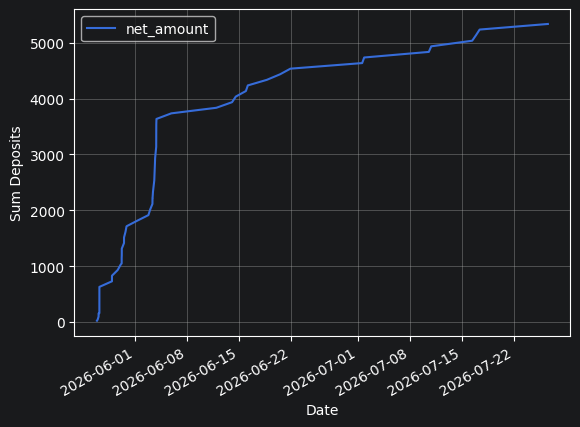

In [75]:
(data_deposits
 .sort_values('date')
 .pipe(lambda x: x[x['status'] != 'FAILED'])
 .assign(net_amount=lambda x: x['net_amount'].cumsum())
 .plot.line(x='date', y='net_amount')
 )
plt.xlabel('Date')
plt.ylabel('Sum Deposits')
plt.grid()

In [76]:
(data_deposits
 .sort_values('date')
 .pipe(lambda x: x[x['status'] != 'FAILED'])
 .pivot_table(index='date', columns='account', values='net_amount', aggfunc='sum', fill_value=0)
 )

account,Visa debit 3333,Visa debit 5895
date,,
2026-05-26 19:39:34+00:00,0.0,25.00
2026-05-26 21:58:29+00:00,0.0,20.00
2026-05-27 00:43:01+00:00,0.0,50.00
2026-05-27 00:56:05+00:00,0.0,10.00
2026-05-27 00:57:28+00:00,0.0,50.00
2026-05-27 03:29:11+00:00,0.0,5.00
2026-05-27 03:29:39+00:00,0.0,10.00
2026-05-27 03:30:06+00:00,0.0,10.00
2026-05-27 03:30:50+00:00,0.0,50.00


In [77]:
(data_deposits
 .pipe(lambda x: x[x['status'] != 'FAILED'])
 .groupby('account')
 ['net_amount']
 .sum()
 )

account
Visa debit 3333    5000.00
Visa debit 5895     335.96
Name: net_amount, dtype: float64